# Description

This is an example of using the [Deepsensor package](https://alan-turing-institute.github.io/deepsensor/index.html) to infer surface NO2 concentrations with multiple input data sources.

[Installation instructions for the Deepsensor package and dependencies.](https://alan-turing-institute.github.io/deepsensor/getting-started/installation.html)

## Setup
Use the Kernel: `Python [conda env:.conda-deepsensor_cenv]`

In [1]:
import os
import logging
logging.captureWarnings(True)

import numpy as np
import xarray as xr
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

import deepsensor.torch
from deepsensor.data import DataProcessor
from deepsensor.data import TaskLoader
from deepsensor.data import construct_circ_time_ds
from deepsensor.model import ConvNP
from deepsensor.train import Trainer, set_gpu_default_device

# input data
s_data_folder = "/discover/nobackup/cmalings/input/ASIA-AQ GCAS Simulation"
# working data folder and file
processor_dir = "/discover/nobackup/cmalings/output/ASIA-AQ/deepsensor_working_data/test_1/"
data_fpath = os.path.join(processor_dir,"tmp.nc")

__*Note*__: to enable plotting of new regions, the region must be defined for the deepsensor plotting function.

File to modify: `/discover/nobackup/cmalings/.conda/envs/deepsensor_cenv/lib/python3.13/site-packages/deepsensor/plot.py`

Function to modufy: `extent_str_to_tuple` (line 1068)

Modification to make: add to the list
```
elif extent == 'new_region':
    return (min_lon,max_lon,min_lat,max_lat)
```

__*Also Note*__: Plotting is currently not working on NCCS Jupyterhub since this doesn't have the internet access needed to download the shapefiles. A temporary workaround is included for showing results.

__*Also Also Note*__: Saving of trained models as jsons is broken. Not sure why. Something to do with being unable to interpret the numpy floating-point values. This has worked on my personal machine.

## Load Data

In [2]:
# Days with GCAS overflight:
l_days = [
          '20240217',
          '20240223',
          '20240226',
          '20240301',
          '20240302',
          '20240303',
          '20240307',
          '20240309'
          ]
# Variables of interest:
l_data_subset = ['GCAS_no2_vertical_column_below_aircraft',
                 'GCAS_model_no2_vertical_column_below_aircraft',
                 'GEMS_AerosolLayerHeigth(ALH)',
                 'GEMS_AerosolOpticalDepth(AOD)',
                 'GEMS_ColumnAmountNO2',
                 'GEMS_ColumnAmountNO2Strat',
                 'GEMS_ColumnAmountNO2Trop',
                 'GEMS_ColumnAmountO3',
                 'GEMS_RootMeanSquareError',
                 'GEOSCF_NO2_level_72',
                 'GEOSCF_NO2_level_37',
                 'GEOSCF_TROPCOL_NO2',
                 'GEOSCF_TOTCOL_NO2',
                 'GEOSCF_NO2_surface',
                 'GEOSCF_TROPPB',
                 'GEOSCF_U_level_72',
                 'GEOSCF_V_level_72',
                 'EMISSIONS_NO2_AREA',
                 'EMISSIONS_NO2_SHIPPING_INT',
                 'EMISSIONS_NO2_SHIPPING_DOM',
                 'EMISSIONS_NO2_ONROAD',
                 'EMISSIONS_NO2_POINT',
                 'EMISSIONS_NO2_TOTAL',
                 'TROPOMI_DAY_no2',
                 'RGM_NO2']
# Load combined dataset:
l_data_combined = []
for s_day in l_days:
    a_combined_day = xr.open_dataset(os.path.join(s_data_folder,'Combined_Data_{}.nc'.format(s_day)))[l_data_subset]
    l_data_combined += [a_combined_day]
a_data_combined = xr.concat(l_data_combined,'time').transpose('time','lat','lon')
# Surface NO2 as target dataset:
l_data_subset.remove('RGM_NO2')
a_data_context = a_data_combined[l_data_subset]
a_data_target = a_data_combined['RGM_NO2']
# Convert to data frame:
f_data_target = a_data_target.to_dataframe().dropna()

# !!! Create additional training data via rotations...

# Process Data
data_processor = DataProcessor(x1_name="lat", x2_name="lon")

f_target_processed = data_processor(f_data_target, method='positive_semidefinite')
a_context_processed = data_processor(a_data_context)

## Define a Task

In [3]:
task_loader = TaskLoader(
    context=[
              a_context_processed[['GCAS_no2_vertical_column_below_aircraft',
                                 ]],
              a_context_processed[['GEMS_ColumnAmountNO2',
                                 'GEMS_ColumnAmountNO2Trop',
                                 ]],
              a_context_processed[['GEOSCF_TROPCOL_NO2',
                                  'GEOSCF_TOTCOL_NO2',
                                  'GEOSCF_NO2_surface',
                                  'GEOSCF_TROPPB',
                                  'GEOSCF_U_level_72',
                                  'GEOSCF_V_level_72',
                                  ]],
              a_context_processed[[
                                  'EMISSIONS_NO2_TOTAL'
                                  ]],
              a_context_processed[['TROPOMI_DAY_no2',
                                  ]]
                                ],
     target=f_target_processed['RGM_NO2'],
    links=[(0, 0)],
)
print(task_loader)

TaskLoader(5 context sets, 1 target sets)
Context variable IDs: (('GCAS_no2_vertical_column_below_aircraft',), ('GEMS_ColumnAmountNO2', 'GEMS_ColumnAmountNO2Trop'), ('GEOSCF_TROPCOL_NO2', 'GEOSCF_TOTCOL_NO2', 'GEOSCF_NO2_surface', 'GEOSCF_TROPPB', 'GEOSCF_U_level_72', 'GEOSCF_V_level_72'), ('EMISSIONS_NO2_TOTAL',), ('TROPOMI_DAY_no2',))
Target variable IDs: (('RGM_NO2',),)


### Visualize an example context & target pair

time: 2024-02-17 01:30:00
ops: []
X_c: [((1, 201), (1, 201)), ((1, 201), (1, 201)), ((1, 201), (1, 201)), ((1, 201), (1, 201)), ((1, 201), (1, 201))]
Y_c: [(1, 201, 201), (2, 201, 201), (6, 201, 201), (1, 201, 201), (1, 201, 201)]
X_t: [(2, 299)]
Y_t: [(1, 299)]



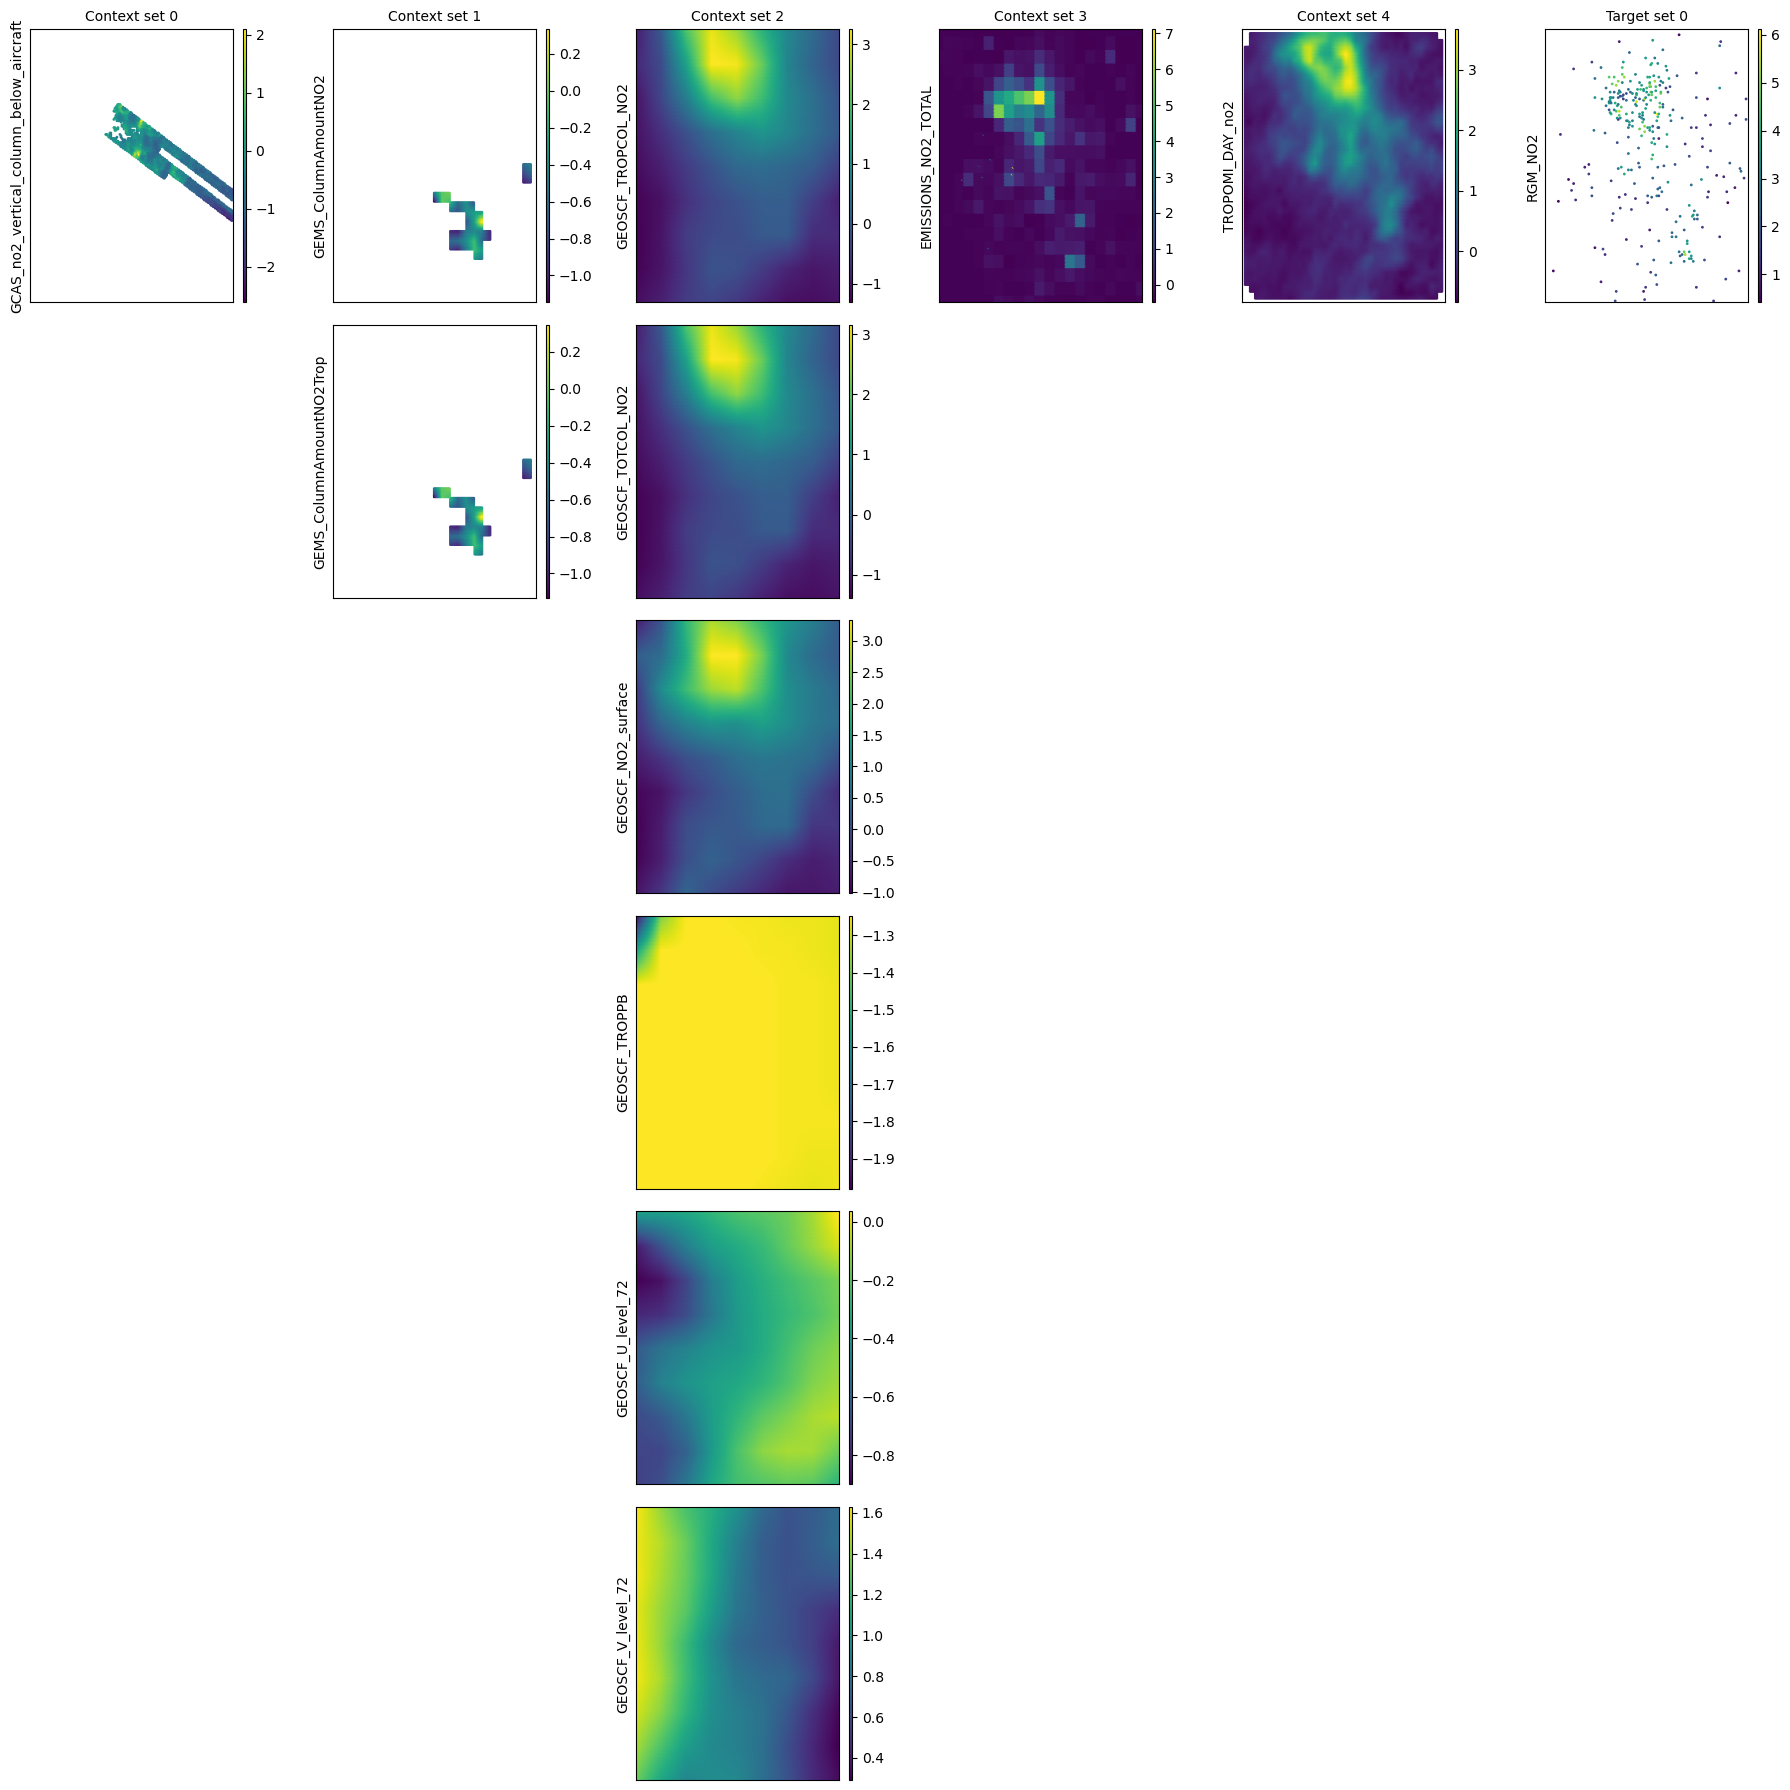

In [4]:
task = task_loader('2024-02-17 01:30:00', context_sampling="all", target_sampling="all")
print(task)

deepsensor.plot.task(task, task_loader)
plt.show()

## Define a Convolutional Neural Process Model

dim_yc inferred from TaskLoader: (1, 2, 6, 1, 1)
dim_yt inferred from TaskLoader: 1
dim_aux_t inferred from TaskLoader: 0
internal_density inferred from TaskLoader: 195
encoder_scales inferred from TaskLoader: [np.float32(0.0025641024), np.float32(0.0025641024), np.float32(0.0025641024), np.float32(0.0025641024), np.float32(0.0025641024)]
decoder_scale inferred from TaskLoader: 0.005128205128205128
SetConv encoding tensor shape: (1, 16, 256, 256)


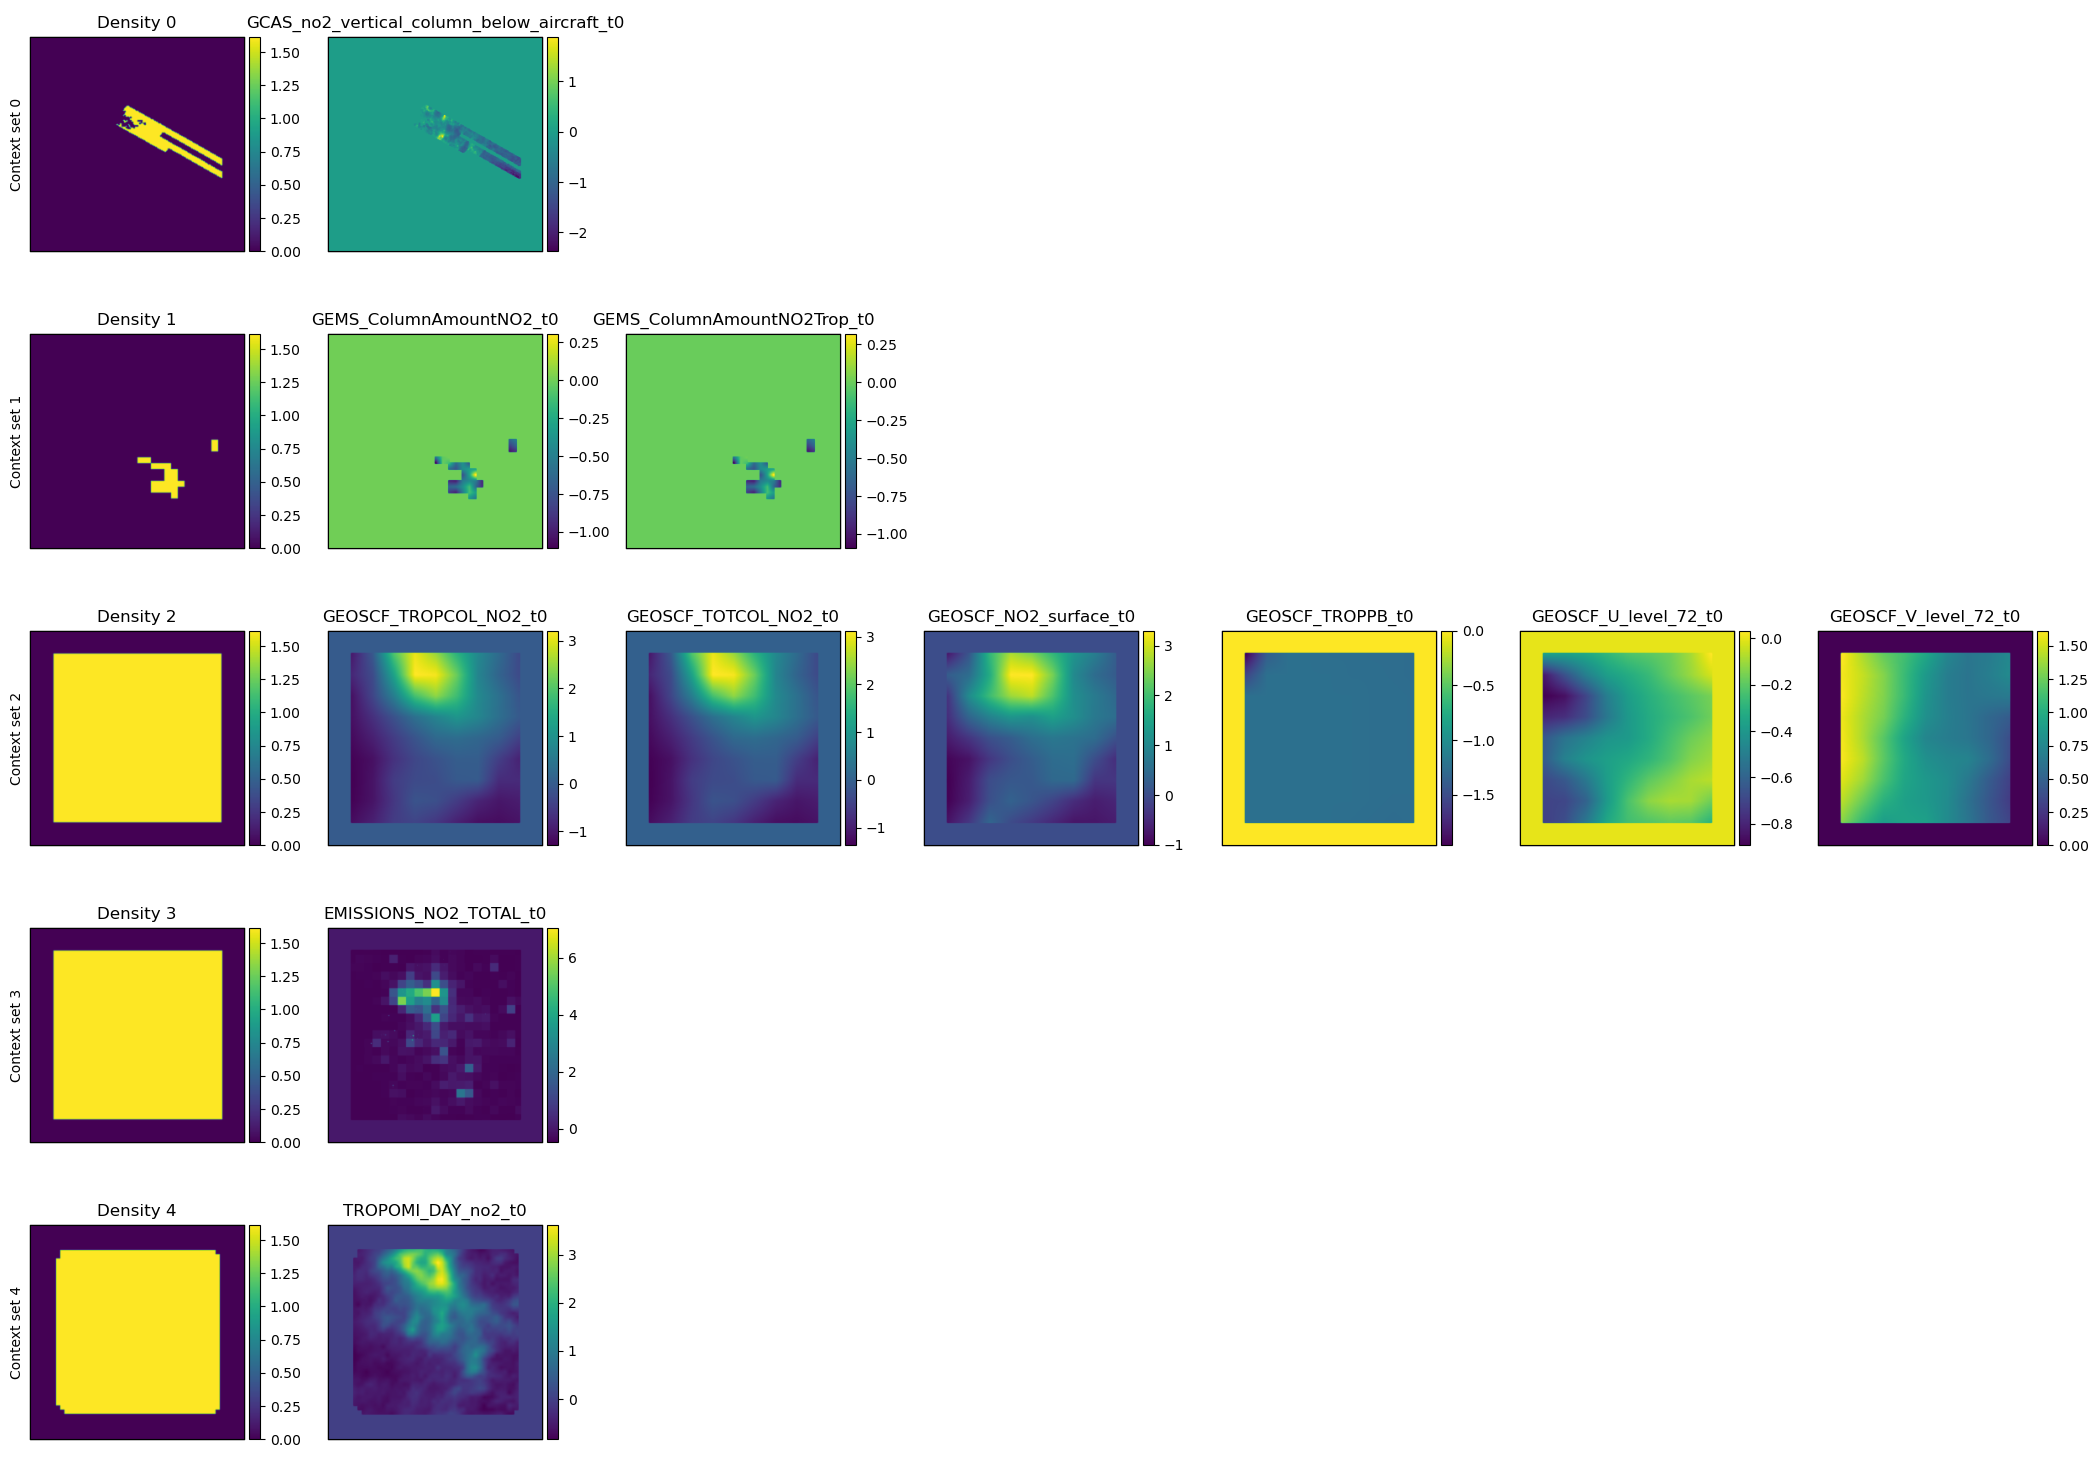

TypeError: Object of type float32 is not JSON serializable

In [14]:
model = ConvNP(data_processor, task_loader, unet_channels=(32, 32, 32, 32, 32))
# print(model)

# encode a task to tensor and visualize the encoding
task = task_loader("2024-02-17 01:30:00'", "all", "all")
encoding = deepsensor.model.nps.compute_encoding_tensor(model, task)
print(f"SetConv encoding tensor shape: {encoding.shape}")
fig = deepsensor.plot.context_encoding(model, task, task_loader)
plt.show()

# visualize the receptive field (note: will not work without internet access to download shapefiles)
# fig = deepsensor.plot.receptive_field(model.model.receptive_field, data_processor, ccrs.PlateCarree(), "seoul")
# fig.axes[0].add_feature(cfeature.BORDERS, linestyle=':')
# plt.show()

# Save the model
model.save(processor_dir) # !!! Model saving also may not work

## Set Up Training

In [20]:
task_loader.load_dask()

# Define task Generator
def gen_tasks(dates, progress=True):
    tasks = []
    for date in dates:
        # N_c = np.random.randint(0, 500)
        task = task_loader(date, context_sampling=["all","all", "all", "all", "all"], target_sampling="all")
        tasks.append(task)
    return tasks

# Split times into training and evaluation sets:
train_range = (
'2024-02-17T00:30:00', 
'2024-02-17T01:30:00',
'2024-02-17T02:30:00', 
'2024-02-17T04:30:00', 
'2024-02-17T05:30:00',
'2024-02-17T06:30:00', 
'2024-02-17T07:30:00',
'2024-02-17T08:30:00', 
'2024-02-23T02:30:00', 
'2024-02-23T03:30:00',
'2024-02-23T04:30:00', 
'2024-02-26T01:30:00',
'2024-02-26T02:30:00', 
'2024-02-26T03:30:00',
'2024-02-26T04:30:00', 
'2024-02-26T05:30:00',
'2024-03-01T00:30:00', 
'2024-03-01T01:30:00',
'2024-03-01T03:30:00',
'2024-03-01T04:30:00', 
'2024-03-01T05:30:00',
'2024-03-02T00:30:00', 
'2024-03-02T01:30:00',
'2024-03-02T02:30:00', 
'2024-03-02T03:30:00',
'2024-03-03T00:30:00',
'2024-03-03T02:30:00',
'2024-03-03T03:30:00', 
'2024-03-03T04:30:00',
'2024-03-07T23:30:00', 
#'2024-03-08T00:30:00',
#'2024-03-08T01:30:00',
#'2024-03-08T02:30:00',
#'2024-03-08T03:30:00', 
#'2024-03-08T04:30:00',
#'2024-03-08T06:30:00', 
#'2024-03-08T07:30:00',
#'2024-03-08T08:30:00', 
#'2024-03-10T00:30:00',
#'2024-03-10T01:30:00', 
#'2024-03-10T02:30:00',
#'2024-03-10T03:30:00', 
#'2024-03-10T04:30:00',
#'2024-03-10T06:30:00', 
#'2024-03-10T07:30:00',
#'2024-03-10T08:30:00',
)

val_range = (
'2024-02-17T03:30:00',
'2024-02-23T05:30:00', 
'2024-02-26T00:30:00', 
'2024-03-01T02:30:00', 
'2024-03-02T04:30:00', 
'2024-03-03T01:30:00',
)

# Generate Evaliation Tasks
val_tasks = gen_tasks(val_range)

# Check number of model parameters
_ = model(val_tasks[0])
print(f"Model has {deepsensor.backend.nps.num_params(model.model):,} parameters")

# Define loss function
def compute_val_rmse(model, val_tasks):
    errors = []
    target_var_ID = task_loader.target_var_IDs[0][0]  # assume 1st target set and 1D
    for task in val_tasks:
        mean = data_processor.map_array(model.mean(task), target_var_ID, unnorm=True)
        true = data_processor.map_array(task["Y_t"][0], target_var_ID, unnorm=True)
        errors.extend(np.abs(mean - true))
    return np.sqrt(np.nanmean(np.concatenate(errors) ** 2)) # RMSE loss

# test that the loss function computes:
print('Loss funcion of untrained model: {}'.format(compute_val_rmse(model, val_tasks)))



Model has 345,992 parameters
Loss funcion of untrained model: 9.791557312011719


## Training

In [21]:
losses = []
val_rmses = []
n_max_epoch = 50

val_rmse_best = np.inf
trainer = Trainer(model, lr=5e-5)
for epoch in range(n_max_epoch):
    train_tasks = gen_tasks(train_range)
    batch_losses = trainer(train_tasks)
    losses.append(np.mean(batch_losses))
    val_rmses.append(compute_val_rmse(model, val_tasks))
    if val_rmses[-1] < val_rmse_best:
        val_rmse_best = val_rmses[-1]
        # model.save(processor_dir) # !!! Model saving doesn't work !!!
    print('Training epoch {} of {}; loss {}'.format(epoch+1,n_max_epoch,val_rmse_best))
          
# visualize loss function improvement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses)
axes[1].plot(val_rmses)
_ = axes[0].set_xlabel("Epoch")
_ = axes[1].set_xlabel("Epoch")
_ = axes[0].set_title("Training loss")
_ = axes[1].set_title("Validation RMSE")

Training epoch 0 of 50; loss 6.518208026885986
Training epoch 1 of 50; loss 6.518208026885986
Training epoch 2 of 50; loss 6.518208026885986
Training epoch 3 of 50; loss 6.319951057434082
Training epoch 4 of 50; loss 6.269285678863525
Training epoch 5 of 50; loss 6.240004539489746
Training epoch 6 of 50; loss 6.139532089233398
Training epoch 7 of 50; loss 6.080667018890381
Training epoch 8 of 50; loss 5.99430513381958
Training epoch 9 of 50; loss 5.99430513381958
Training epoch 10 of 50; loss 5.99430513381958
Training epoch 11 of 50; loss 5.99430513381958
Training epoch 12 of 50; loss 5.99430513381958
Training epoch 13 of 50; loss 5.99430513381958
Training epoch 14 of 50; loss 5.99430513381958
Training epoch 15 of 50; loss 5.916705131530762
Training epoch 16 of 50; loss 5.916705131530762
Training epoch 17 of 50; loss 5.787377834320068
Training epoch 18 of 50; loss 5.746712684631348
Training epoch 19 of 50; loss 5.62614107131958
Training epoch 20 of 50; loss 5.62614107131958
Training ep

## Visualize Trained Model Output

In [73]:
# Pick a result to plot
date = '2024-02-17T03:30:00'
# date = '2024-03-01T02:30:00'
test_task = task_loader(date, context_sampling=["all", "all", "all", "all", "all"], target_sampling="all")
# Define a complete set of coordinates for evaluation:
X_t_all = xr.Dataset({'target':xr.DataArray(np.nan,dims=('lat','lon'),coords={'lat':a_data_combined['lat'],'lon':a_data_combined['lon']})})
# Predict outputs:
pred = model.predict(test_task, X_t=X_t_all, resolution_factor=1)

pred

{'RGM_NO2': <xarray.Dataset> Size: 326kB
 Dimensions:  (time: 1, lat: 201, lon: 201)
 Coordinates:
   * lat      (lat) float64 2kB 36.0 36.01 36.02 36.03 ... 37.97 37.98 37.99 38.0
   * lon      (lon) float64 2kB 126.0 126.0 126.0 126.0 ... 128.0 128.0 128.0
   * time     (time) datetime64[ns] 8B 2024-02-17T03:30:00
 Data variables:
     mean     (time, lat, lon) float32 162kB 6.507 6.25 6.132 ... 7.869 7.922
     std      (time, lat, lon) float32 162kB 2.609 2.375 2.183 ... 3.77 3.994}

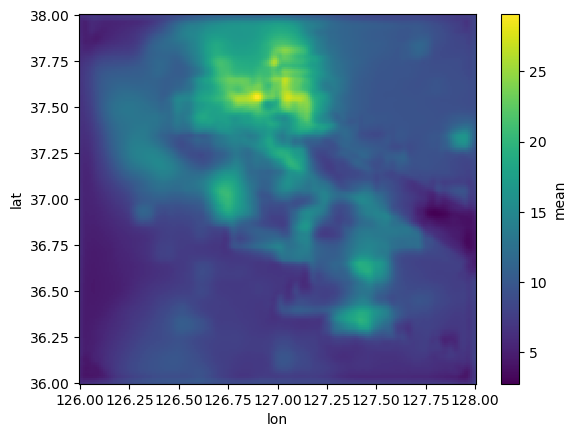

In [75]:
# visualize the prediction
# Plotting doesn't work properly since the shapefiles for the region can't be accessed on Discover.
# o_fig_out = deepsensor.plot.prediction(pred, date, data_processor, task_loader, test_task, crs=ccrs.PlateCarree())
# plt.show()

o_fig_out = pred['RGM_NO2']['mean'].mean('time').plot()
plt.show()



In [76]:
# helper function: plotting on a map
def f_plot_map(a_data_plot,
               a_data_plot_point=None,
               n_lat_min=-90,
               n_lat_max=90,
               n_lon_min=-180,
               n_lon_max=180,
               my_cmap = plt.get_cmap('Blues'),
               Colorbar_Label = None,
               Plot_Title = None,
               Colorbar_Limits = None,
               n_pointsize = 20,
               o_figure = None,
               o_axis = None,
               o_plot = None,
               SHOW=True):
  if o_figure is None:
      o_figure,o_axis = plt.subplots(1,1)
      o_axis.remove()
      o_axis = o_figure.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
      # mapobj = plt.figure().add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())

      # mapobj = mapobj.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())


  # mapobj.coastlines();
  # mapobj.add_feature(cartopy.feature.LAKES, edgecolor='black', facecolor='none', linestyle='-');
  # mapobj.set_extent([np.max([n_lon_min,-180])-0.001, np.min([n_lon_max,180])+0.001, np.max([n_lat_min,-90])-0.001, np.min([n_lat_max,90])+0.001])
  o_axis.set_extent([np.max([n_lon_min,-180])-0.001, np.min([n_lon_max,180])+0.001, np.max([n_lat_min,-90])-0.001, np.min([n_lat_max,90])+0.001])
  gridlines = o_axis.gridlines(crs=cartopy.crs.PlateCarree(), xlocs=range(np.int_(np.floor(np.max([n_lon_min,-180]))),np.int_(np.ceil(np.min([n_lon_max,180])))+1), ylocs=range(np.int_(np.floor(np.max([n_lat_min,-90]))),np.int_(np.ceil(np.min([n_lat_max,90])))+1), draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
  gridlines.top_labels = False
  gridlines.right_labels = False
  if 'time' in a_data_plot.dims:
      # take average for plotting:
      a_data_plot = a_data_plot.mean(dim='time')
  if Colorbar_Limits is None:
      if Colorbar_Label is not None:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,cbar_kwargs={'label': Colorbar_Label})
      else:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap)
  else:
      if Colorbar_Label is not None:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cbar_kwargs={'label': Colorbar_Label})
      else:
        o_plot = a_data_plot.plot(ax=o_axis,cmap=my_cmap,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1])
  if a_data_plot_point is not None:
    v_lat_plot = np.array(a_data_plot_point.lat)
    v_lon_plot = np.array(a_data_plot_point.lon)
    if 'time' in a_data_plot_point.dims:
      # take average for plotting:
      v_data_temp = np.array(a_data_plot_point.mean(dim='time'))
    else:
      v_data_temp = np.array(a_data_plot_point)
    if Colorbar_Limits is None:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,cmap=my_cmap)
    else:
      o_plot_point = o_axis.scatter(x=v_lon_plot,y=v_lat_plot,s=n_pointsize,edgecolors='k',c=v_data_temp,vmin=Colorbar_Limits[0],vmax=Colorbar_Limits[1],cmap=my_cmap)
#    if Colorbar_Label is not None:
#      o_axis.colorbar().set_label(Colorbar_Label)
#    else:
#      o_axis.colorbar()
  if Plot_Title is not None:
    o_axis.set_title(Plot_Title)
  if SHOW:
    o_figure.show()
  return o_figure,o_axis,o_plot

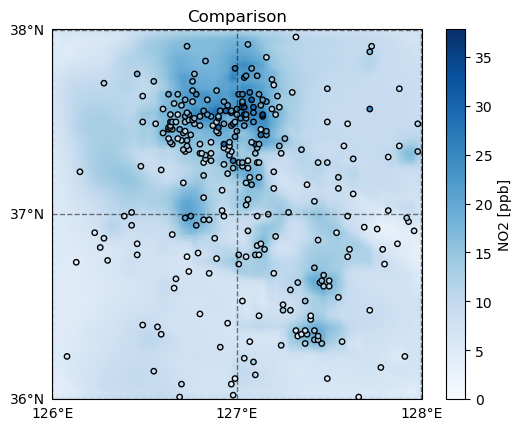

In [82]:
# plot results for comparison
o_fig,o_ax,o_plot =  f_plot_map(pred['RGM_NO2']['mean'].mean('time'),
                                a_data_plot_point = a_data_target.sel(time=date).stack(latlon=('lat','lon')).dropna(dim='latlon',how='all'),
                                n_lat_min=36,
                                n_lat_max=38,
                                n_lon_min=126,
                                n_lon_max=128,
                                my_cmap = plt.get_cmap('Blues'),
                                Colorbar_Label = 'NO2 [ppb]',
                                Plot_Title = 'Comparison',
                                Colorbar_Limits = (0,a_data_target.sel(time=date).stack(latlon=('lat','lon')).dropna(dim='latlon',how='all').values.max()),
                                n_pointsize=15)
o_fig

# Next Steps to be worked on
 - Quantitative evaluation of performance, compare to interpolation (or nearest) ground station
 - Augment training data with rotations
 - Add additional context information
   - Higher resolution emissions
   - Population
   - Land use/cover
   - time-of-day indicators
 - Test when inputs (e.g., GCAS) are missing
 - Include some ground stations as inputs; set-up appropriate cross-validation
 - Evaluate importance of different input types
 - Work on importing context data at original resolutions to avoid need for regridding?
   - This would allow much easier predictions at other times since there wouldn't need to be a high-res gridded dataset of everything to pull from